# MOSAIC Demonstration: 3D Displacement Analysis in CaTiO3

This notebook assembles the 3D CaTiO3 displacement workflow into a single place, using the checked-in JSON configurations in `examples/config_3D/displacement/`.

The workflow follows the paper-style displacement decomposition described in the example README:
1. inspect the CaTiO3 structure and the checked-in mask configurations
2. visualise the reciprocal-space partition into `all`, `sphere`, `rod`, and `rest`
3. run MOSAIC for each mask variant using the existing `run_parameters_*.json` files
4. load decoded site-resolved displacement vectors from all runs
5. compare the reconstructed displacements to the ground truth from `Catio3.rmc6f` and `Catio3_average.rmc6f`
6. verify linearity: `u_rod + u_sphere + u_rest ≈ u_all`

The full and small CaTiO3 workflows now use the same app pattern: all mask variants share one M-decoder source directory, so filtered outputs are decoded with the same displacement decoder as the unfiltered reference.

For this 3D displacement case, the selected real-space points are the three oxygen sublattices (`refNumber = 2, 3, 4`) inside the `16 x 16 x 16` cell box.



In [1]:
import os
import sys
import json
import re
import csv
import subprocess
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

MOSAIC_ROOT = Path(os.path.abspath('')).parent
if str(MOSAIC_ROOT) not in sys.path:
    sys.path.insert(0, str(MOSAIC_ROOT))

from core.config.factories.configuration_factory import RMC6fProcessorFactory

EXAMPLE_DIR = Path('config_3D/displacement')
STRUCTURE_FILE = 'Catio3.rmc6f'
AVERAGE_FILE = 'Catio3_average.rmc6f'

RUN_FILES = {
    'all': EXAMPLE_DIR / 'run_parameters_all.json',
    'sphere': EXAMPLE_DIR / 'run_parameters_sphere.json',
    'rod': EXAMPLE_DIR / 'run_parameters_rod.json',
    'rest': EXAMPLE_DIR / 'run_parameters_rest.json',
}

print(f'MOSAIC root   : {MOSAIC_ROOT}')
print(f'Example dir   : {EXAMPLE_DIR}')
print(f'Structure     : {STRUCTURE_FILE}')
print(f'Average file  : {AVERAGE_FILE}')
for tag, path in RUN_FILES.items():
    print(f'Run file [{tag:6s}] : {path}')



MOSAIC root   : <repo>
Example dir   : config_3D/displacement
Structure     : Catio3.rmc6f
Average file  : Catio3_average.rmc6f
Run file [all   ] : config_3D/displacement/run_parameters_all.json
Run file [sphere] : config_3D/displacement/run_parameters_sphere.json
Run file [rod   ] : config_3D/displacement/run_parameters_rod.json
Run file [rest  ] : config_3D/displacement/run_parameters_rest.json


## 1. Inspect the Structure and Configuration JSONs

The displacement analysis uses the actual CaTiO3 configuration together with a separate average structure. The checked-in JSONs define a reciprocal-space partition around the `1/2(111)` superlattice features:
- `all`    : full reciprocal-space reference
- `sphere` : interior of the superlattice sphere (`r = 0.2501` r.l.u.)
- `rod`    : cylindrical rod around `(h,k) = (1/2, 1/2)` excluding the sphere
- `rest`   : everything outside both the rod and the sphere

All four configs point to the same decoder compute directory, `./output_disp_decoder`, matching the small notebook's shared-decoder workflow.



In [2]:
def load_run_bundle(run_path: Path):
    run_payload = json.loads(run_path.read_text(encoding='utf-8'))
    input_path = (run_path.parent / run_payload['input_parameters_path']).resolve()
    if not input_path.exists():
        # handle absolute path payloads as well
        input_path = Path(run_payload['input_parameters_path'])
    input_payload = json.loads(input_path.read_text(encoding='utf-8'))
    return run_payload, input_path, input_payload

bundles = {}
for tag, run_path in RUN_FILES.items():
    bundles[tag] = load_run_bundle(run_path)

processor = RMC6fProcessorFactory().create_processor(
    str((EXAMPLE_DIR / STRUCTURE_FILE).resolve()),
    processor_type='read',
    average_file_path=str((EXAMPLE_DIR / AVERAGE_FILE).resolve()),
)
processor.process()

vectors = processor.get_vectors()
actual = processor.get_coordinates().copy()
average = processor.get_average_coordinates().copy()
cell_ids = processor.get_cell_ids().copy()
elements = processor.get_elements().copy()
refnumbers = processor.get_refnumbers().copy()

df = pd.DataFrame({
    'element': elements.to_numpy(),
    'refnumber': refnumbers.to_numpy(),
    'x': actual['x'].to_numpy(),
    'y': actual['y'].to_numpy(),
    'z': actual['z'].to_numpy(),
    'xav': average['x'].to_numpy(),
    'yav': average['y'].to_numpy(),
    'zav': average['z'].to_numpy(),
    'cell_x': cell_ids['x'].to_numpy(),
    'cell_y': cell_ids['y'].to_numpy(),
    'cell_z': cell_ids['z'].to_numpy(),
})

cell_min = np.array(bundles['all'][2]['structure']['cell_limits']['min'])
cell_max = np.array(bundles['all'][2]['structure']['cell_limits']['max'])
mask_box = (
    (df['cell_x'] >= cell_min[0]) & (df['cell_x'] <= cell_max[0]) &
    (df['cell_y'] >= cell_min[1]) & (df['cell_y'] <= cell_max[1]) &
    (df['cell_z'] >= cell_min[2]) & (df['cell_z'] <= cell_max[2])
)
mask_points = mask_box & (df['element'] == 'O') & (df['refnumber'].isin([2, 3, 4]))
selected = df.loc[mask_points].copy()

lengths = np.array([np.linalg.norm(vectors[i, :]) for i in range(3)])
for comp, L in zip(['ux_true', 'uy_true', 'uz_true'], lengths):
    pass
selected['ux_true'] = selected['x'] - selected['xav']
selected['uy_true'] = selected['y'] - selected['yav']
selected['uz_true'] = selected['z'] - selected['zav']
selected['ux_true'] -= np.round(selected['ux_true'] / lengths[0]) * lengths[0]
selected['uy_true'] -= np.round(selected['uy_true'] / lengths[1]) * lengths[1]
selected['uz_true'] -= np.round(selected['uz_true'] / lengths[2]) * lengths[2]
selected['u_true_mag'] = np.sqrt(selected['ux_true']**2 + selected['uy_true']**2 + selected['uz_true']**2)

print('Cell lengths (A):', lengths)
print('Total atoms       :', len(df))
print('Selected O sites  :', len(selected))
print('Selected by ref   :')
print(selected.groupby('refnumber').size())
print()
print('Mask summary from JSONs:')
for tag, (_, input_path, payload) in bundles.items():
    print(f'[{tag}] input  : {input_path.name}')
    print(f'[{tag}] output : {payload["paths"]["output_directory"]}')
    print(f'[{tag}] mask   : {payload["reciprocal_space"]["mask"]["equation"]}')
    print(f'[{tag}] chunks : {payload["processing"]["num_chunks"]}, backend={payload["runtime"]["dask"]["backend"]}')
    print(f'[{tag}] decoder: {payload["processing"].get("decoder")}')
    print()


Cell lengths (A): [59.7976 59.7976 60.72  ]
Total atoms       : 20480
Selected O sites  : 12288
Selected by ref   :
refnumber
2    4096
3    4096
4    4096
dtype: int64

Mask summary from JSONs:
[all] input  : input_parameters_all.json
[all] output : ./output_disp_all
[all] mask   : (((Mod(h,1.0) - 0.5)**2 + (Mod(k,1.0) - 0.5)**2 + (Mod(l,1.0) - 0.5)**2) >= 0)
[all] chunks : 4, backend=local
[all] decoder: {'source': 'compute', 'compute_output_directory': './output_disp_decoder'}

[sphere] input  : input_parameters_sphere.json
[sphere] output : ./output_disp_sphere
[sphere] mask   : (((Mod(h,1.0) - 0.5)**2 + (Mod(k,1.0) - 0.5)**2 + (Mod(l,1.0) - 0.5)**2) < (0.2501)**2)
[sphere] chunks : 4, backend=local
[sphere] decoder: {'source': 'compute', 'compute_output_directory': './output_disp_decoder'}

[rod] input  : input_parameters_rod.json
[rod] output : ./output_disp_rod
[rod] mask   : (((Mod(h,1.0) - 0.5)**2 + (Mod(k,1.0) - 0.5)**2) <= (0.1876)**2) & (((Mod(h,1.0) - 0.5)**2 + (Mod(k,1.0)

## 2. Reciprocal-Space Partition from the JSON Masks

The `rod` mask is easiest to interpret in a slice that cuts through the rod axis. The figure below shows the mask geometry in the `(k,l)` plane at fixed `h = 0.5` r.l.u., centered on a `1/2(111)` superstructure point.


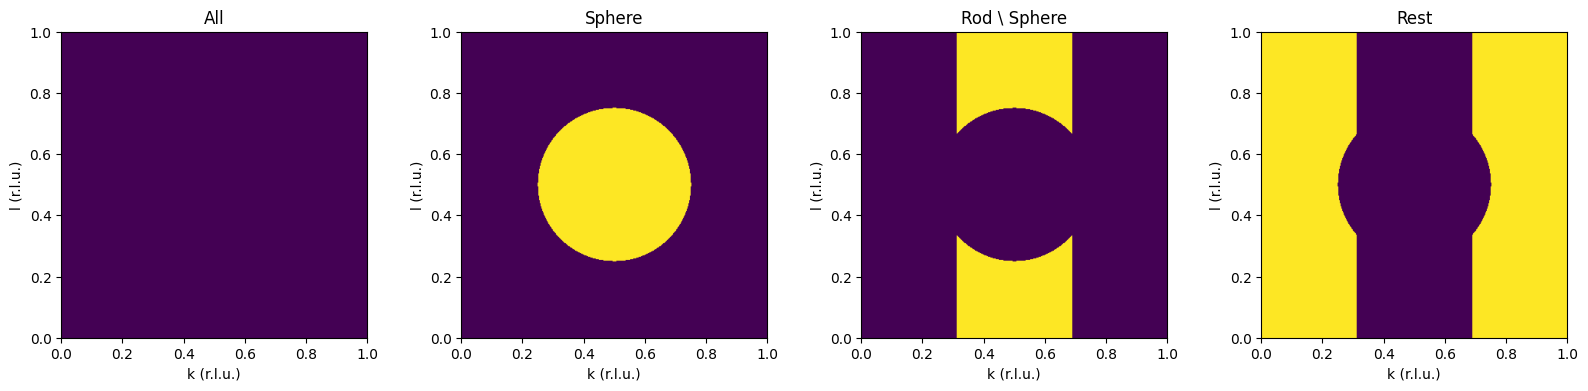

In [3]:
ROD_R = 0.1876
SPHERE_R = 0.2501
h0 = 0.5
k = np.linspace(0.0, 1.0, 401)
l = np.linspace(0.0, 1.0, 401)
K, L = np.meshgrid(k, l)

def mod_half(x):
    return np.mod(x, 1.0) - 0.5

dh = mod_half(np.full_like(K, h0))
dk = mod_half(K)
dl = mod_half(L)
rod = (dh**2 + dk**2 <= ROD_R**2) & (dh**2 + dk**2 + dl**2 >= SPHERE_R**2)
sphere = (dh**2 + dk**2 + dl**2 < SPHERE_R**2)
rest = (dh**2 + dk**2 > ROD_R**2) & (dh**2 + dk**2 + dl**2 > SPHERE_R**2)
all_mask = np.ones_like(rod, dtype=bool)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), constrained_layout=True)
for ax, arr, title in zip(
    axes,
    [all_mask, sphere, rod, rest],
    ['All', 'Sphere', 'Rod \\ Sphere', 'Rest'],
):
    ax.imshow(arr.astype(float), origin='lower', extent=[k.min(), k.max(), l.min(), l.max()], cmap='viridis', aspect='equal')
    ax.set_title(title)
    ax.set_xlabel('k (r.l.u.)')
    ax.set_ylabel('l (r.l.u.)')
plt.show()


## 3. Run MOSAIC from the Checked-In `run_parameters_*.json`

Each cell below launches MOSAIC in a fresh subprocess to avoid Jupyter event-loop issues. These are research-scale 3D runs and may take substantial time and memory.


In [ ]:
from example_runner import run_mosaic_case


def run_mosaic(tag: str):
    # Shared launcher: venv CUDA libs on LD_LIBRARY_PATH, scratch on real
    # disk (never tmpfs), streaming architecture on, workers auto-sized to
    # visible GPUs (1-GPU laptop .. multi-GPU node), kernel-death safe.
    run_mosaic_case(RUN_FILES[tag], repo_root=MOSAIC_ROOT, tag=tag)


### Run 1/4: Unfiltered (all reciprocal space)


In [5]:
run_mosaic('all')


Running MOSAIC -- ALL
2026-07-07 11:45:48,981 - [INFO] - core.runtime.logger_config - (logger_config.py:40) - Logging configuration loaded from logging.conf
2026-07-07 11:45:48,981 - [INFO] - app - (main.py:84) - Using input parameters: config_3D/displacement/input_parameters_all.json
2026-07-07 11:45:48,981 - [INFO] - app - (main.py:85) - Resolved configuration root: examples/config_3D/displacement
2026-07-07 11:45:48,981 - [INFO] - app - (main.py:86) - Runtime settings: backend=local max_workers=2 threads_per_worker=16 processes=False
2026-07-07 11:45:49,277 - [INFO] - core.patch_centers.from_average - (from_average.py:132) - Processing parameters for 'from_average' method with fresh start.
2026-07-07 11:45:49,277 - [INFO] - core.patch_centers.from_average - (from_average.py:144) - Processing parameters for 'from_average' method.
2026-07-07 11:45:49,278 - [INFO] - core.patch_centers.from_average - (from_average.py:101) - Cell-box filter: kept 20480 points, dropped 0 outside [[0, 0, 0

Residual-field:  14%|█▍        | 5/36 [01:05<06:43, 13.01s/batch, done=chunk0/p4:1-320 (n=320) | running=3 | elapsed=1.1m | eta=6.7m | rate=0.1/s]

2026-07-07 11:48:37,157 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:118) - Residual-field queue [#####...............] 9/36 (25%) | running=4 | chunk=0 | intervals=1-320 (n=320)


Residual-field:  42%|████▏     | 15/36 [03:54<05:27, 15.62s/batch, done=chunk1/p4:1-320 (n=320) | running=3 | elapsed=3.9m | eta=5.5m | rate=0.1/s]

2026-07-07 11:51:26,254 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:118) - Residual-field queue [##########..........] 18/36 (50%) | running=4 | chunk=1 | intervals=1-320 (n=320)


...

2026-07-07 11:57:21,624 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:118) - Residual-field queue [###############.....] 27/36 (75%) | running=4 | chunk=2 | intervals=1-320 (n=320)


Residual-field:  92%|█████████▏| 33/36 [12:04<01:05, 21.97s/batch, done=chunk3/p4:1-320 (n=320) | running=3 | elapsed=12.1m | eta=1.1m | rate=0.0/s]

2026-07-07 11:59:37,023 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:118) - Residual-field queue [####################] 36/36 (100%) | running=4 | chunk=3 | intervals=1-320 (n=320)


Residual-field: 100%|██████████| 36/36 [13:22<00:00, 22.29s/batch, done=chunk3/p8:1-320 (n=320) | running=0 | elapsed=13.4m]                        


2026-07-07 12:00:54,932 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 0) | writes=1 | bytes=126705678 | wall=0.000s
2026-07-07 12:00:54,932 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 1) | writes=1 | bytes=126335214 | wall=0.000s
2026-07-07 12:00:54,932 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 2) | writes=1 | bytes=126335214 | wall=0.000s
2026-07-07 12:00:54,932 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 3) | writes=1 | bytes=126705678 | wall=0.000s
2026-07-07 12:00:54,932 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) 

### Run 2/4: Sphere (superlattice nanodomain signal)


In [6]:
run_mosaic('sphere')


Running MOSAIC -- SPHERE
2026-07-07 12:01:59,949 - [INFO] - core.runtime.logger_config - (logger_config.py:40) - Logging configuration loaded from logging.conf
2026-07-07 12:01:59,949 - [INFO] - app - (main.py:84) - Using input parameters: config_3D/displacement/input_parameters_sphere.json
2026-07-07 12:01:59,949 - [INFO] - app - (main.py:85) - Resolved configuration root: examples/config_3D/displacement
2026-07-07 12:01:59,949 - [INFO] - app - (main.py:86) - Runtime settings: backend=local max_workers=2 threads_per_worker=16 processes=False
2026-07-07 12:02:00,264 - [INFO] - core.patch_centers.from_average - (from_average.py:132) - Processing parameters for 'from_average' method with fresh start.
2026-07-07 12:02:00,265 - [INFO] - core.patch_centers.from_average - (from_average.py:144) - Processing parameters for 'from_average' method.
2026-07-07 12:02:00,267 - [INFO] - core.patch_centers.from_average - (from_average.py:101) - Cell-box filter: kept 20480 points, dropped 0 outside [[0

Residual-field:  14%|█▍        | 5/36 [00:38<03:58,  7.68s/batch, done=chunk0/p4:1-256 (n=256) | running=3 | elapsed=38s | eta=4.0m | rate=0.1/s] 

2026-07-07 12:03:34,771 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:118) - Residual-field queue [#####...............] 9/36 (25%) | running=4 | chunk=0 | intervals=1-256 (n=256)


Residual-field:  39%|███▉      | 14/36 [01:42<02:40,  7.32s/batch, done=chunk1/p4:1-256 (n=256) | running=3 | elapsed=1.7m | eta=2.7m | rate=0.1/s]

2026-07-07 12:04:38,814 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:118) - Residual-field queue [##########..........] 18/36 (50%) | running=4 | chunk=1 | intervals=1-256 (n=256)


...

2026-07-07 12:08:10,715 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:118) - Residual-field queue [###############.....] 27/36 (75%) | running=4 | chunk=2 | intervals=1-256 (n=256)


Residual-field:  89%|████████▉ | 32/36 [11:58<01:29, 22.45s/batch, done=chunk3/p4:1-256 (n=256) | running=3 | elapsed=12.0m | eta=1.5m | rate=0.0/s]

2026-07-07 12:14:54,629 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:118) - Residual-field queue [####################] 36/36 (100%) | running=4 | chunk=3 | intervals=1-256 (n=256)


Residual-field: 100%|██████████| 36/36 [13:23<00:00, 22.31s/batch, done=chunk3/p8:1-256 (n=256) | running=0 | elapsed=13.4m]                        


2026-07-07 12:16:19,799 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 0) | writes=1 | bytes=126705166 | wall=0.000s
2026-07-07 12:16:19,800 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 1) | writes=1 | bytes=126334702 | wall=0.000s
2026-07-07 12:16:19,800 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 2) | writes=1 | bytes=126334702 | wall=0.000s
2026-07-07 12:16:19,800 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 3) | writes=1 | bytes=126705166 | wall=0.000s
2026-07-07 12:16:19,800 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) 

### Run 3/4: Rod \ Sphere (anisotropic rod-like component)


In [7]:
run_mosaic('rod')


Running MOSAIC -- ROD
2026-07-07 12:17:30,966 - [INFO] - core.runtime.logger_config - (logger_config.py:40) - Logging configuration loaded from logging.conf
2026-07-07 12:17:30,967 - [INFO] - app - (main.py:84) - Using input parameters: config_3D/displacement/input_parameters_rod.json
2026-07-07 12:17:30,967 - [INFO] - app - (main.py:85) - Resolved configuration root: examples/config_3D/displacement
2026-07-07 12:17:30,967 - [INFO] - app - (main.py:86) - Runtime settings: backend=local max_workers=2 threads_per_worker=16 processes=False
2026-07-07 12:17:31,277 - [INFO] - core.patch_centers.from_average - (from_average.py:132) - Processing parameters for 'from_average' method with fresh start.
2026-07-07 12:17:31,277 - [INFO] - core.patch_centers.from_average - (from_average.py:144) - Processing parameters for 'from_average' method.
2026-07-07 12:17:31,280 - [INFO] - core.patch_centers.from_average - (from_average.py:101) - Cell-box filter: kept 20480 points, dropped 0 outside [[0, 0, 0

Residual-field:  14%|█▍        | 5/36 [00:46<04:49,  9.34s/batch, done=chunk0/p4:1-320 (n=320) | running=3 | elapsed=47s | eta=4.8m | rate=0.1/s]

2026-07-07 12:19:27,952 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:118) - Residual-field queue [#####...............] 9/36 (25%) | running=4 | chunk=0 | intervals=1-320 (n=320)


Residual-field:  42%|████▏     | 15/36 [02:06<02:57,  8.44s/batch, done=chunk1/p4:1-320 (n=320) | running=3 | elapsed=2.1m | eta=3.0m | rate=0.1/s]

2026-07-07 12:20:47,814 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:118) - Residual-field queue [##########..........] 18/36 (50%) | running=4 | chunk=1 | intervals=1-320 (n=320)


...

2026-07-07 12:22:10,566 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:118) - Residual-field queue [###############.....] 27/36 (75%) | running=4 | chunk=2 | intervals=1-320 (n=320)


Residual-field:  92%|█████████▏| 33/36 [05:53<00:32, 10.73s/batch, done=chunk3/p4:1-320 (n=320) | running=3 | elapsed=5.9m | eta=32s | rate=0.1/s] 

2026-07-07 12:24:35,235 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:118) - Residual-field queue [####################] 36/36 (100%) | running=4 | chunk=3 | intervals=1-320 (n=320)


Residual-field: 100%|██████████| 36/36 [06:17<00:00, 10.50s/batch, done=chunk3/p8:1-320 (n=320) | running=0 | elapsed=6.3m]                       


2026-07-07 12:24:59,489 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 0) | writes=1 | bytes=126705678 | wall=0.000s
2026-07-07 12:24:59,489 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 1) | writes=1 | bytes=126335214 | wall=0.000s
2026-07-07 12:24:59,489 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 2) | writes=1 | bytes=126335214 | wall=0.000s
2026-07-07 12:24:59,489 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 3) | writes=1 | bytes=126705678 | wall=0.000s
2026-07-07 12:24:59,489 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) 

### Run 4/4: Rest (complementary reciprocal space)


In [8]:
run_mosaic('rest')


Running MOSAIC -- REST
2026-07-07 12:26:04,499 - [INFO] - core.runtime.logger_config - (logger_config.py:40) - Logging configuration loaded from logging.conf
2026-07-07 12:26:04,500 - [INFO] - app - (main.py:84) - Using input parameters: config_3D/displacement/input_parameters_rest.json
2026-07-07 12:26:04,500 - [INFO] - app - (main.py:85) - Resolved configuration root: examples/config_3D/displacement
2026-07-07 12:26:04,500 - [INFO] - app - (main.py:86) - Runtime settings: backend=local max_workers=2 threads_per_worker=16 processes=False
2026-07-07 12:26:04,817 - [INFO] - core.patch_centers.from_average - (from_average.py:132) - Processing parameters for 'from_average' method with fresh start.
2026-07-07 12:26:04,817 - [INFO] - core.patch_centers.from_average - (from_average.py:144) - Processing parameters for 'from_average' method.
2026-07-07 12:26:04,819 - [INFO] - core.patch_centers.from_average - (from_average.py:101) - Cell-box filter: kept 20480 points, dropped 0 outside [[0, 0,

Residual-field:  14%|█▍        | 5/36 [01:22<08:30, 16.47s/batch, done=chunk0/p4:1-320 (n=320) | running=3 | elapsed=1.4m | eta=8.5m | rate=0.1/s] 

2026-07-07 12:29:13,813 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:118) - Residual-field queue [#####...............] 9/36 (25%) | running=4 | chunk=0 | intervals=1-320 (n=320)


Residual-field:  42%|████▏     | 15/36 [03:14<04:32, 12.98s/batch, done=chunk1/p4:1-320 (n=320) | running=3 | elapsed=3.2m | eta=4.5m | rate=0.1/s]

2026-07-07 12:31:06,107 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:118) - Residual-field queue [##########..........] 18/36 (50%) | running=4 | chunk=1 | intervals=1-320 (n=320)


...

2026-07-07 12:32:14,622 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:118) - Residual-field queue [###############.....] 27/36 (75%) | running=4 | chunk=2 | intervals=1-320 (n=320)


Residual-field:  89%|████████▉ | 32/36 [07:02<00:52, 13.21s/batch, done=chunk3/p5:1-320 (n=320) | running=3 | elapsed=7.0m | eta=53s | rate=0.1/s] 

2026-07-07 12:34:54,259 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:118) - Residual-field queue [####################] 36/36 (100%) | running=4 | chunk=3 | intervals=1-320 (n=320)


Residual-field: 100%|██████████| 36/36 [07:27<00:00, 12.43s/batch, done=chunk3/p8:1-320 (n=320) | running=0 | elapsed=7.5m]                       


2026-07-07 12:35:19,307 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 0) | writes=1 | bytes=126705678 | wall=0.000s
2026-07-07 12:35:19,307 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 1) | writes=1 | bytes=126335214 | wall=0.000s
2026-07-07 12:35:19,307 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 2) | writes=1 | bytes=126335214 | wall=0.000s
2026-07-07 12:35:19,307 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 3) | writes=1 | bytes=126705678 | wall=0.000s
2026-07-07 12:35:19,307 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) 

## 4. Load the Decoded 3D Displacement Fields

The displacement decoder writes per-site vectors as `chunk_*_site_displacements.csv`. We concatenate all chunks and align the results by `central_point_id`, which corresponds to the filtered oxygen-site indices used by the `from_average` point processor.

Because all full-case configs use the shared decoder directory `./output_disp_decoder`, the `all`, `sphere`, `rod`, and `rest` fields are decoded with the same M-decoder.



In [9]:
def load_displacements(output_dir: Path):
    proc_dir = output_dir / 'processed_point_data'
    csv_paths = sorted(proc_dir.glob('chunk_*_site_displacements.csv'))
    if not csv_paths:
        csv_paths = sorted(proc_dir.glob('output_chunk_*_first_moment_displacements.csv'))
    if not csv_paths:
        raise FileNotFoundError(f'No displacement CSV files found in {proc_dir}')

    frames = []
    for csv_path in csv_paths:
        frame = pd.read_csv(csv_path, sep='	')
        frames.append(frame)
    df_u = pd.concat(frames, ignore_index=True)
    df_u = df_u.sort_values('central_point_id').reset_index(drop=True)
    return df_u

output_dirs = {tag: Path(bundle[2]['paths']['output_directory']) for tag, bundle in bundles.items()}
results = {}
for tag, out in output_dirs.items():
    results[tag] = load_displacements(EXAMPLE_DIR / out)
    print(tag, len(results[tag]), 'sites loaded from', out)

selected_sorted = selected.sort_index().copy()
for tag, frame in results.items():
    if not np.array_equal(frame['central_point_id'].to_numpy(), selected_sorted.index.to_numpy()):
        raise ValueError(f'central_point_id mismatch for {tag}')
    selected_sorted[f'ux_{tag}'] = frame['ux'].to_numpy()
    selected_sorted[f'uy_{tag}'] = frame['uy'].to_numpy()
    selected_sorted[f'uz_{tag}'] = frame['uz'].to_numpy()
    selected_sorted[f'u_{tag}_mag'] = np.sqrt(frame['ux'].to_numpy()**2 + frame['uy'].to_numpy()**2 + frame['uz'].to_numpy()**2)

print()
print('RMS displacement magnitudes:')
for tag in ['all', 'sphere', 'rod', 'rest']:
    print(f'  {tag:6s}: {np.sqrt(np.mean(selected_sorted[f"u_{tag}_mag"]**2)):.4f} A')
print(f'  true  : {np.sqrt(np.mean(selected_sorted["u_true_mag"]**2)):.4f} A')


all 12288 sites loaded from output_disp_all
sphere 12288 sites loaded from output_disp_sphere
rod 12288 sites loaded from output_disp_rod
rest 12288 sites loaded from output_disp_rest

RMS displacement magnitudes:
  all   : 0.2236 A
  sphere: 0.1651 A
  rod   : 0.0993 A
  rest  : 0.1135 A
  true  : 0.2241 A


## 5. Mid-Plane Displacement Maps

To keep the 3D field readable, we visualise one oxygen sublattice (`refNumber = 2`) in a single mid-cell slab. This exposes the displacement texture in the `x-y` plane while still using the full 3D reconstruction under the hood.


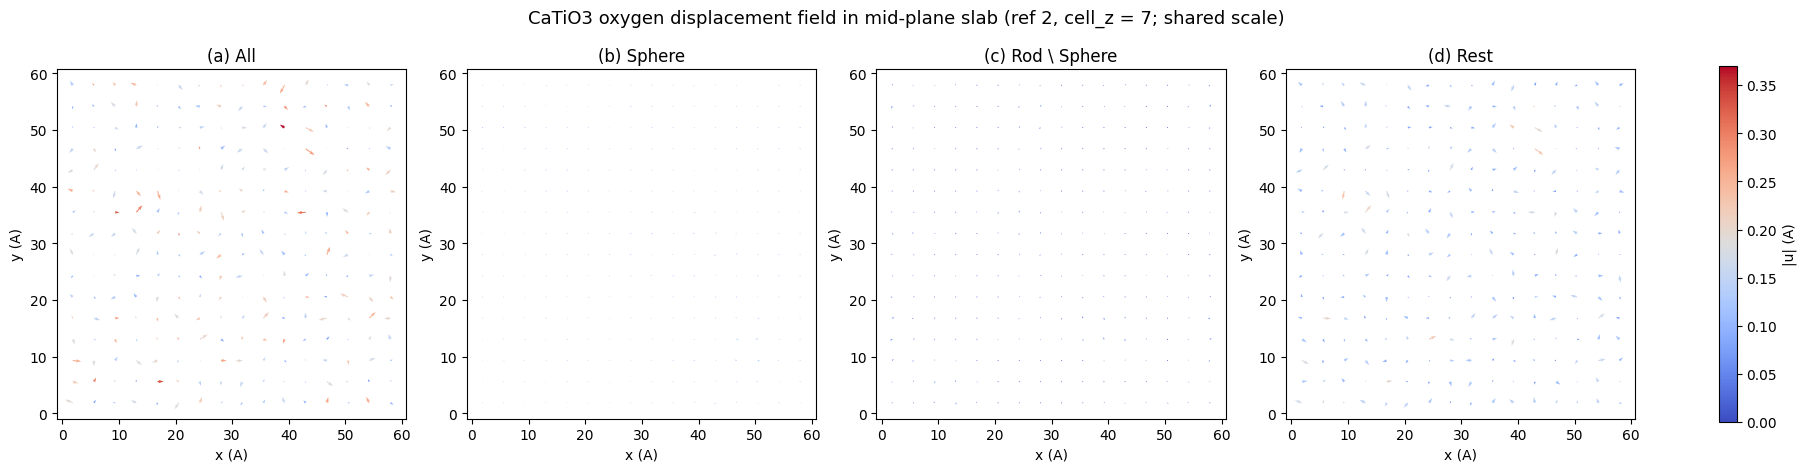

In [10]:
plot_ref = 2
plot_z = int(np.median(selected_sorted['cell_z']))
slab = selected_sorted[(selected_sorted['refnumber'] == plot_ref) & (selected_sorted['cell_z'] == plot_z)].copy()
slab = slab.sort_values(['cell_y', 'cell_x']).reset_index(drop=True)

datasets = [
    ('all', '(a) All'),
    ('sphere', '(b) Sphere'),
    ('rod', '(c) Rod \ Sphere'),
    ('rest', '(d) Rest'),
]

# Shared colour and vector scale for all panels.
all_mags = np.concatenate([slab[f'u_{tag}_mag'].to_numpy() for tag, _ in datasets])
color_norm = Normalize(vmin=0.0, vmax=float(np.nanmax(all_mags)))
vector_scale = 0.12

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), constrained_layout=True)
q = None
for ax, (tag, title) in zip(axes, datasets):
    mag = slab[f'u_{tag}_mag'].to_numpy()
    q = ax.quiver(
        slab['xav'].to_numpy(),
        slab['yav'].to_numpy(),
        slab[f'ux_{tag}'].to_numpy(),
        slab[f'uy_{tag}'].to_numpy(),
        mag,
        cmap='coolwarm',
        norm=color_norm,
        angles='xy',
        scale_units='xy',
        scale=vector_scale,
        width=0.003,
    )
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_xlabel('x (A)')
    ax.set_ylabel('y (A)')

fig.colorbar(q, ax=axes, shrink=0.82, label='|u| (A)')
fig.suptitle(f'CaTiO3 oxygen displacement field in mid-plane slab (ref {plot_ref}, cell_z = {plot_z}; shared scale)', fontsize=13, y=1.03)
plt.show()



## 6. Ground-Truth Comparison and Linearity Check

The notebook checks two things:
1. **Ground truth**: compare the unfiltered MOSAIC displacement vectors to the actual displacements from `Catio3.rmc6f - Catio3_average.rmc6f`
2. **Linearity**: verify that `u_sphere + u_rod + u_rest ≈ u_all`


Linearity check: sphere + rod + rest = all
  RMS |u_all|      : 0.223599 A
  RMS residual     : 5.29e-08 A
  Relative error   : 2.37e-07

Ground truth check: u_all vs u_true
  RMS |u_true|     : 0.224112 A
  RMS residual     : 1.10e-02 A
  Relative error   : 4.90e-02

Ground truth check (per-component -- the parity metric):
  Component Pearson r        : 0.9988
  Best-fit slope (all/true)  : 0.9965
  Mean direction cosine      : 0.9996
  Flipped sites (cos < 0)    : 0.00%


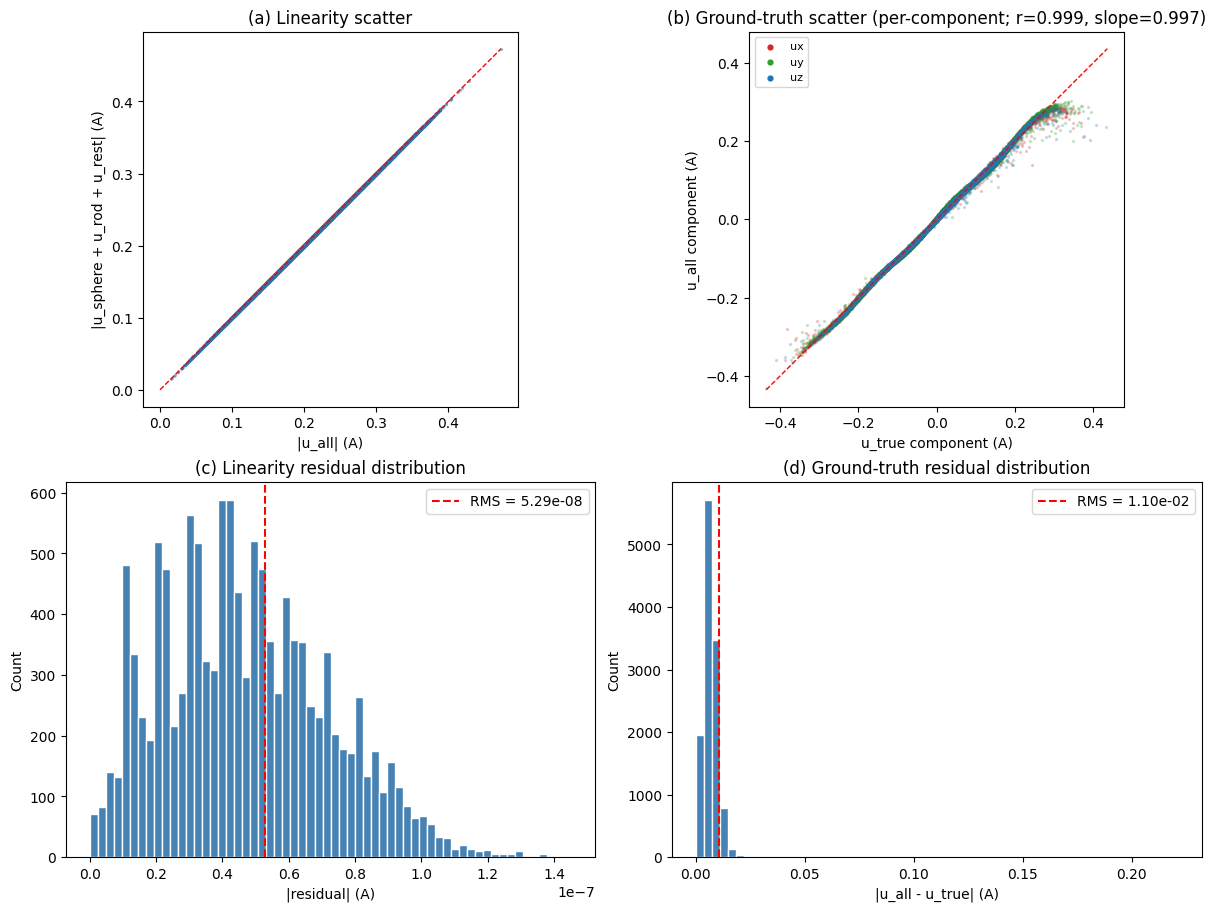

In [11]:
ux_true = selected_sorted['ux_true'].to_numpy()
uy_true = selected_sorted['uy_true'].to_numpy()
uz_true = selected_sorted['uz_true'].to_numpy()

ux_all = selected_sorted['ux_all'].to_numpy()
uy_all = selected_sorted['uy_all'].to_numpy()
uz_all = selected_sorted['uz_all'].to_numpy()

ux_sum = selected_sorted['ux_sphere'].to_numpy() + selected_sorted['ux_rod'].to_numpy() + selected_sorted['ux_rest'].to_numpy()
uy_sum = selected_sorted['uy_sphere'].to_numpy() + selected_sorted['uy_rod'].to_numpy() + selected_sorted['uy_rest'].to_numpy()
uz_sum = selected_sorted['uz_sphere'].to_numpy() + selected_sorted['uz_rod'].to_numpy() + selected_sorted['uz_rest'].to_numpy()

resid_lin = np.sqrt((ux_sum - ux_all)**2 + (uy_sum - uy_all)**2 + (uz_sum - uz_all)**2)
resid_gt = np.sqrt((ux_all - ux_true)**2 + (uy_all - uy_true)**2 + (uz_all - uz_true)**2)
full_mag = selected_sorted['u_all_mag'].to_numpy()
true_mag = selected_sorted['u_true_mag'].to_numpy()
sum_mag = np.sqrt(ux_sum**2 + uy_sum**2 + uz_sum**2)

rms_lin = np.sqrt(np.mean(resid_lin**2))
rms_gt = np.sqrt(np.mean(resid_gt**2))
rms_full = np.sqrt(np.mean(full_mag**2))
rms_true = np.sqrt(np.mean(true_mag**2))

# Signed per-component arrays. Validate the vector reconstruction on the
# components, NOT on |u|: the magnitude is a positive-definite (folded) quantity,
# so per-site reconstruction noise turns into an upward-biased fan in a
# |u_all| vs |u_true| scatter even when the underlying vectors sit on the line.
# The component scatter (panel b) is the honest parity plot.
comp_true = np.concatenate([ux_true, uy_true, uz_true])
comp_all = np.concatenate([ux_all, uy_all, uz_all])
comp_r = np.corrcoef(comp_true, comp_all)[0, 1]
comp_slope = np.sum(comp_true * comp_all) / np.sum(comp_true**2)
cos_align = np.sum(np.stack([ux_all, uy_all, uz_all]) * np.stack([ux_true, uy_true, uz_true]), axis=0) / (
    np.maximum(full_mag * true_mag, 1e-30))

print('Linearity check: sphere + rod + rest = all')
print(f'  RMS |u_all|      : {rms_full:.6f} A')
print(f'  RMS residual     : {rms_lin:.2e} A')
print(f'  Relative error   : {rms_lin / rms_full:.2e}')
print()
print('Ground truth check: u_all vs u_true')
print(f'  RMS |u_true|     : {rms_true:.6f} A')
print(f'  RMS residual     : {rms_gt:.2e} A')
print(f'  Relative error   : {rms_gt / rms_true:.2e}')
print()
print('Ground truth check (per-component -- the parity metric):')
print(f'  Component Pearson r        : {comp_r:.4f}')
print(f'  Best-fit slope (all/true)  : {comp_slope:.4f}')
print(f'  Mean direction cosine      : {cos_align.mean():.4f}')
print(f'  Flipped sites (cos < 0)    : {np.mean(cos_align < 0):.2%}')

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)

ax = axes[0, 0]
ax.plot([0, max(full_mag.max(), sum_mag.max())], [0, max(full_mag.max(), sum_mag.max())], 'r--', lw=1)
ax.scatter(full_mag, sum_mag, s=2, alpha=0.35)
ax.set_xlabel('|u_all| (A)')
ax.set_ylabel('|u_sphere + u_rod + u_rest| (A)')
ax.set_title('(a) Linearity scatter')
ax.set_aspect('equal')

ax = axes[1, 0]
ax.hist(resid_lin, bins=60, color='steelblue', edgecolor='white')
ax.axvline(rms_lin, color='red', ls='--', label=f'RMS = {rms_lin:.2e}')
ax.set_xlabel('|residual| (A)')
ax.set_ylabel('Count')
ax.set_title('(c) Linearity residual distribution')
ax.legend()

# (b) Per-component parity: stack ux, uy, uz of decoded vs true. This collapses
# onto y = x when the reconstruction is good, unlike the magnitude scatter which
# folds direction agreement away and fans out near the origin by construction.
ax = axes[0, 1]
comp_lim = float(np.max(np.abs(np.concatenate([comp_true, comp_all]))))
ax.plot([-comp_lim, comp_lim], [-comp_lim, comp_lim], 'r--', lw=1)
for comp_t, comp_a, comp_c in (
    (ux_true, ux_all, 'tab:red'),
    (uy_true, uy_all, 'tab:green'),
    (uz_true, uz_all, 'tab:blue'),
):
    ax.scatter(comp_t, comp_a, s=2, alpha=0.2, color=comp_c)
ax.scatter([], [], s=12, color='tab:red', label='ux')
ax.scatter([], [], s=12, color='tab:green', label='uy')
ax.scatter([], [], s=12, color='tab:blue', label='uz')
ax.set_xlabel('u_true component (A)')
ax.set_ylabel('u_all component (A)')
ax.set_title(f'(b) Ground-truth scatter (per-component; r={comp_r:.3f}, slope={comp_slope:.3f})')
ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=8)

ax = axes[1, 1]
ax.hist(resid_gt, bins=60, color='steelblue', edgecolor='white')
ax.axvline(rms_gt, color='red', ls='--', label=f'RMS = {rms_gt:.2e}')
ax.set_xlabel('|u_all - u_true| (A)')
ax.set_ylabel('Count')
ax.set_title('(d) Ground-truth residual distribution')
ax.legend()

plt.show()


### Reading panel (b)

Panel (b) compares the *signed* displacement components against the ground truth. Component-wise comparison is used because a magnitude-vs-magnitude scatter is biased upward for small displacements; the signed components sit symmetrically on the y = x line when the reconstruction is good. The configured real-space patch step satisfies the sampling requirement for this `hkl` range.


## 7. Summary

This single notebook wraps the CaTiO3 3D displacement case around the checked-in JSON configurations.

It is intended for the paper-style interpretation of the reciprocal-space partition:
- **sphere** isolates the compact `1/2(111)` superlattice contribution
- **rod** isolates the cylindrical rod-like signal outside the sphere
- **rest** captures the complementary background
- **all** is the full reference field

The key validation for this case is linearity of the displacement reconstruction:
\[
\mathbf{u}_{\mathrm{sphere}} + \mathbf{u}_{\mathrm{rod}} + \mathbf{u}_{\mathrm{rest}} \\approx \mathbf{u}_{\mathrm{all}}.
\]



In [12]:
# --- Cleanup (optional) ---
# Uncomment to remove generated output directories after inspection.
# for tag, bundle in bundles.items():
#     out = EXAMPLE_DIR / Path(bundle[2]['paths']['output_directory'])
#     if out.exists():
#         shutil.rmtree(out)
#         print(f'Removed {out}')
